#電信客戶流失預測與留客策略報告 (基於 XAI 模型可解釋性)

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
import shap 
# 1. 讀取與清洗資料
print("正在載入並清洗資料...")
data_url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(data_url)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
df['Churn_Target'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 2. 特徵篩選與編碼 (排除共線性與無效變數)
drop_cols = ['gender', 'PhoneService', 'TotalCharges', 'Churn', 'customerID', 'Churn_Target']
X = df.drop(columns=drop_cols)
y = df['Churn_Target']
X = pd.get_dummies(X, drop_first=True) # 將文字類別轉為 0 與 1

# 3. 切割資料與 SMOTE 平衡
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# 4. 訓練隨機森林模型
print("正在訓練 Random Forest 模型...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_smote, y_train_smote)

# 5. 基本成效評估
y_pred = rf_model.predict(X_test)
print("\n=== 模型分類報告 ===")
print(classification_report(y_test, y_pred))


正在載入並清洗資料...
正在訓練 Random Forest 模型...

=== 模型分類報告 ===
              precision    recall  f1-score   support

           0       0.84      0.84      0.84      1036
           1       0.55      0.55      0.55       373

    accuracy                           0.76      1409
   macro avg       0.70      0.70      0.70      1409
weighted avg       0.76      0.76      0.76      1409



#核心商業洞察

正在計算 SHAP 影響力數值...


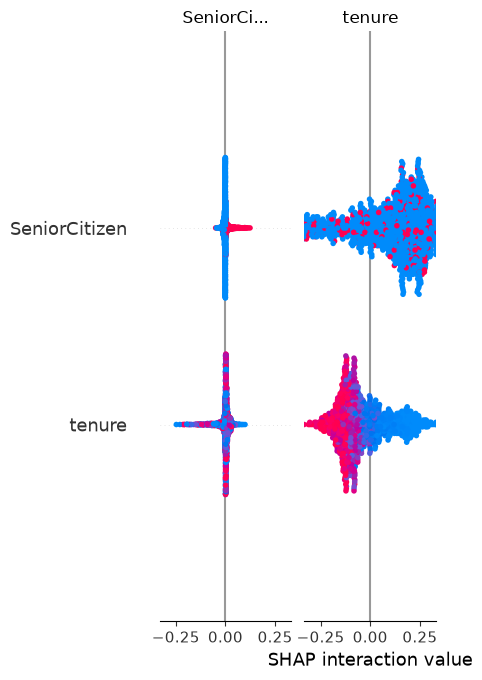

In [6]:
print("正在計算 SHAP 影響力數值...")

# 1. 建立解釋器 
explainer = shap.TreeExplainer(rf_model)

# 2. 計算測試集的 SHAP 值
shap_values = explainer.shap_values(X_test)

# 3. 畫出 SHAP 總結圖 
shap.summary_plot(shap_values[1] if isinstance(shap_values, list) else shap_values, X_test)

## 💡 商業行動建議 (Business Recommendations)

根據上方 SHAP 圖表的特徵影響力分佈（紅色代表數值高，藍色代表數值低；偏右側代表增加流失風險），我們梳理出三大關鍵留客策略：

1. **針對「光纖網路 (Fiber optic)」使用者的痛點盤點:**
   * **洞察：** 圖表中 `InternetService_Fiber optic` 的紅點大量集中在右側，顯示使用光纖網路極度推升流失率。
   * **建議：** 此為異常警訊。建議產品部門立即調閱光纖網路近期的「客訴單」與「斷線頻率報告」，極有可能是硬體品質或定價競爭力出現嚴重瑕疵。
   
2. **把握「新手合約期」的黃金救援點：**
   * **洞察：** `Contract_Two year` (兩年約) 與 `tenure` (年資) 如果數值高 (紅色)，會大幅把點往左拉 (降低流失)。相反地，未綁長約的新客戶極易流失。
   * **建議：** 行銷預算應集中火力在「年資低於 6 個月」且「按月簽約」的新戶。主動推播「升級一年/兩年合約享首月免費」的活動，將其轉化為長期穩定合約。

3. **推動支付方式轉型：**
   * **洞察：** `PaymentMethod_Electronic check` (電子支票) 的使用者流失風險顯著偏高。
   * **建議：** 舉辦「綁定信用卡自動扣款享 50 元折抵」活動，減少客戶每個月手動繳費時的「痛感」與重新評估解約的機會。